# Data Science HW 13: NLP 

### Abdullah Junejo (07154)

In [ ]:
#pip install spacy
#python -m spacy download en_core_web_sm

In [27]:
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('stopwords')
from nltk import pos_tag, word_tokenize, RegexpParser
import spacy
from spacy import displacy
from collections import Counter
import en_core_web_sm
from bs4 import BeautifulSoup
import requests
import re
import numpy

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Q1

In [28]:
#as per online lecture

def url_to_string(url):
    res = requests.get(url)
    html = res.text
    soup = BeautifulSoup(html, 'html.parser')
    for script in soup(["script", "style", 'aside']):
        script.extract()
    return " ".join(re.split(r'[\n\t]+', soup.get_text()))

In [29]:
nlp = en_core_web_sm.load()
ny_bb = url_to_string('https://road.cc/content/tech-news/2024-team-ag2r-van-rysel-road-bikes-unveiled-305325')
article = nlp(ny_bb)
len(article.ents)

347

In [30]:
labels = [x.label_ for x in article.ents]
Counter(labels)

Counter({'DATE': 43,
         'FAC': 12,
         'WORK_OF_ART': 5,
         'PRODUCT': 5,
         'ORG': 128,
         'PERSON': 56,
         'EVENT': 3,
         'GPE': 15,
         'CARDINAL': 25,
         'ORDINAL': 5,
         'NORP': 7,
         'QUANTITY': 4,
         'LANGUAGE': 1,
         'MONEY': 27,
         'TIME': 5,
         'PERCENT': 3,
         'LOC': 3})

In [31]:
items = [x.text for x in article.ents]
Counter(items).most_common(10)

[('Decathlon', 13),
 ('AG2R', 10),
 ('RCR', 10),
 ('Van Rysel', 6),
 ('Ultegra', 6),
 ('first', 5),
 ('XCR', 5),
 ('Rendel Harris', 5),
 ('2024', 4),
 ('French', 4)]

In [32]:
displacy.render(article, style='ent', jupyter=True)

# Analysis

### NER analysis on the road.cc article about 2024 Team AG2R Van Rysel road bikes reveals a strong focus on organizations (ORG), products (PRODUCT), and specific dates (DATE), indicating discussions about cycling teams, bike models, and future events or developments. However, the model exhibits some inaccuracies, such as misclassifying 'Ultegra' (a product name for bike components) as an ORG instead of a PRODUCT. Same for 'Shimano Dura Ace' which was labeled as a 'Person'. This misclassification highlights a shortcoming in the model's ability to correctly interpret specialized terms specific to the cycling industry. Overall, while the model effectively identifies a variety of entities, it demonstrates limitations in contextual understanding and specificity, especially in niche domains.

# Q2

In [34]:
#pip install pypdf2
from PyPDF2 import PdfReader #Had errors with Tika

In [35]:
reader = PdfReader("AJ07154_Analysis.pdf")
text = ""
for page in reader.pages:
    text += page.extract_text()
print(text)

Habib University – ENVS -102 Introduction to Environmental Systems  
 
  
EN-ROADS CLIMATE 
SIMULATOR ANALYSIS  
Polic ies Proposal  
By: Abdullah Junejo  
AJ07154@ST.HABIB.EDU.PK  Abstract  
There is no denying the fact that t he approaching threat of climate change  is imminent. In 
Habib University’s 6th Yohsin Lecture, The renowned linguist, philosopher and social critic, 
Professor Noam Chomsky stated it to be one of the four  things that will lead to a terminal 
disaster and the end of humanity.  The paper will l ook i nto certain set of policies to counter 
the threat of severe climate change using data and projections from  the En-Roads climate 
change simulator  by Climate Interactive and MIT Sloan Sustainability Initiative . Furthermore, 
it will also take a look into the extent of its Goals, realism, the extent of  equity, implications, 
and possible failures.  
1 
EN-ROADS CLIMATE SIMULATOR ANALYSIS  
 
 
 
En-Roads Climate Simulator Analysis  
 
Abdullah Junejo  
Dhanani S

In [45]:
#Filtering out stop words and punctuation from the paper
token_words = nltk.tokenize.word_tokenize(text)
stopwords = nltk.corpus.stopwords.words('english')

#Adding modal verbs and other custom stopwords to the list
custom_stopwords = ["T", "J", "D", "S", "M", "Q", "H", "et al", "et", "pp", "a.", "m.", "d.", "j.", "s.", "r.", "c.", "t.", "s", "can", "would", "could", "might", "many", "also"]
stopwords.extend(custom_stopwords)

#Removing stopwords
no_stopwords = [word for word in token_words if word.lower() not in stopwords]

#Filtering to keep only words with alphabetic characters
nonPunct = re.compile('.*[A-Za-z].*')
filtered = [w for w in no_stopwords if nonPunct.match(w)]

#Calculating frequency distribution of the words
filteredwordfreq = nltk.FreqDist(filtered)

filteredwordfreq.most_common(25)  # Adjust the number as needed

[('energy', 18),
 ('policies', 17),
 ('countries', 14),
 ('April', 13),
 ('change', 12),
 ('nuclear', 12),
 ('population', 12),
 ('https', 12),
 ('EN-ROADS', 11),
 ('CLIMATE', 11),
 ('SIMULATOR', 11),
 ('ANALYSIS', 11),
 ('Retrieved', 11),
 ('take', 10),
 ('increase', 10),
 ('difficult', 10),
 ('electric', 10),
 ('one', 9),
 ('world', 9),
 ('reduce', 9),
 ('Climate', 8),
 ('coal', 8),
 ('usage', 8),
 ('sources', 8),
 ('carbon', 8)]

In [39]:
filteredwordfreq.most_common(20)

[('would', 40),
 ('might', 19),
 ('energy', 18),
 ('policies', 17),
 ('countries', 14),
 ('April', 13),
 ('change', 12),
 ('could', 12),
 ('nuclear', 12),
 ('population', 12),
 ('https', 12),
 ('EN-ROADS', 11),
 ('CLIMATE', 11),
 ('SIMULATOR', 11),
 ('ANALYSIS', 11),
 ('Retrieved', 11),
 ('take', 10),
 ('increase', 10),
 ('difficult', 10),
 ('electric', 10)]

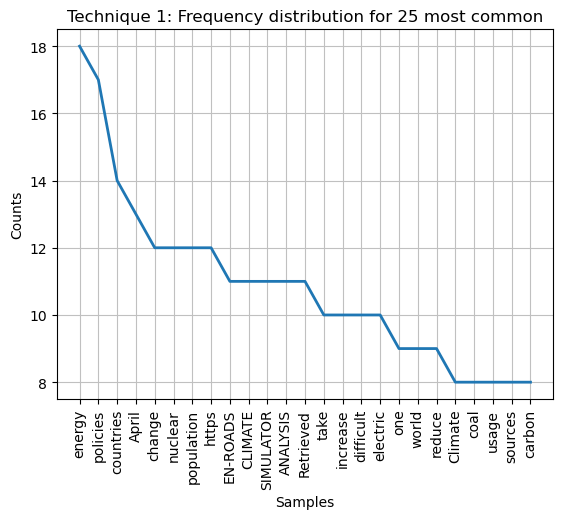

<Axes: title={'center': 'Technique 1: Frequency distribution for 25 most common'}, xlabel='Samples', ylabel='Counts'>

In [47]:
filteredwordfreq.plot(25, title="Technique 1: Frequency distribution for 25 most common")

### The frequency distribution shows a decreasing pattern (Sharp at first, gradual at later). This is a simple technique that simply finds out the common words which can be used to potentially understand the document.

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer #Studied this in detail in The Data Structures 2 Course

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform([text])

#Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

#Get the scores for each feature (word)
scores = zip(feature_names, tfidf_matrix.toarray()[0])
sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)

#Print top N scores
for item in sorted_scores[:25]:  # Adjust N as needed
    print(f"Word: {item[0]}, Score: {item[1]}")


Word: climate, Score: 0.24209363672043027
Word: nuclear, Score: 0.22347104928039718
Word: energy, Score: 0.21415975556038064
Word: en, Score: 0.1676032869602979
Word: simulator, Score: 0.1676032869602979
Word: policies, Score: 0.15829199324028134
Word: roads, Score: 0.15829199324028134
Word: 2022, Score: 0.1489806995202648
Word: world, Score: 0.1489806995202648
Word: countries, Score: 0.13035811208023168
Word: april, Score: 0.12104681836021514
Word: carbon, Score: 0.12104681836021514
Word: change, Score: 0.12104681836021514
Word: population, Score: 0.12104681836021514
Word: analysis, Score: 0.11173552464019859
Word: electric, Score: 0.11173552464019859
Word: https, Score: 0.11173552464019859
Word: fusion, Score: 0.10242423092018205
Word: retrieved, Score: 0.10242423092018205
Word: coal, Score: 0.09311293720016549
Word: difficult, Score: 0.09311293720016549
Word: increase, Score: 0.09311293720016549
Word: oil, Score: 0.08380164348014894
Word: reduce, Score: 0.08380164348014894
Word: tec

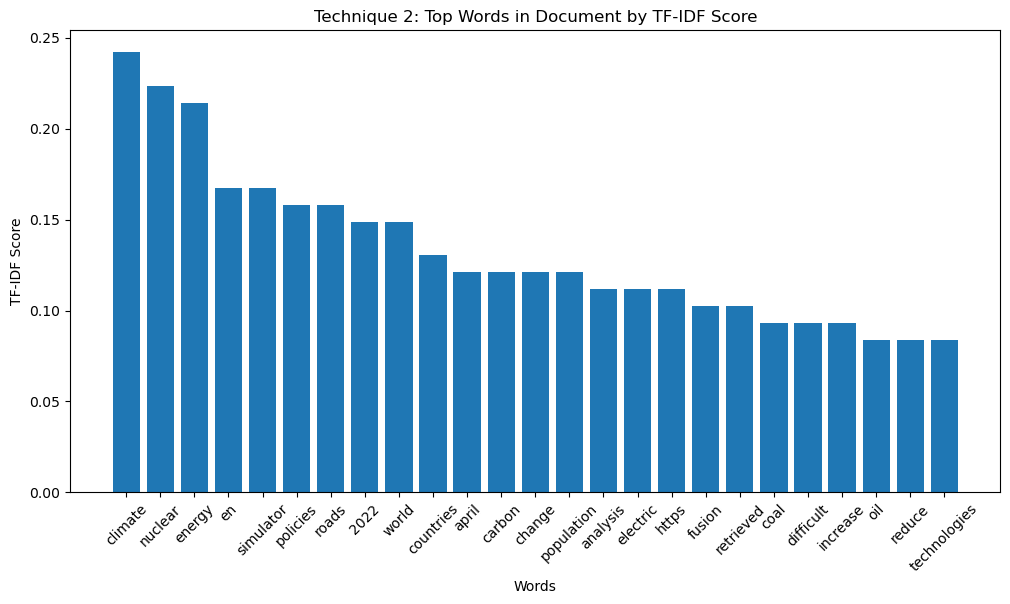

In [53]:
import matplotlib.pyplot as plt

# Extract the top N words and their scores for visualization
top_n = 25
top_words, top_scores = zip(*sorted_scores[:top_n])

# Plotting the top N words with their TF-IDF scores
plt.figure(figsize=(12, 6))
plt.bar(top_words, top_scores)
plt.xlabel('Words')
plt.ylabel('TF-IDF Score')
plt.title('Technique 2: Top Words in Document by TF-IDF Score')
plt.xticks(rotation=45)
plt.show()


### The higher the TF-IDF score, the more unique the word is to the document in the context of a given corpus. This implies that words like "climate," "nuclear," and "energy" are not only frequent in the document but also carry more importance in differentiating this document's content from others. The high scores for "climate," "nuclear," "energy," and "carbon" suggest a document that focuses on environmental issues, energy sources, and possibly climate change. Terms like "policies," "roads," "world," "countries," and "population" indicate a discussion that might be related to environmental policy, infrastructure, and global or demographic considerations. All of which is TRUE. Hence, proving that this technique effectively can even predict the nature of the document, its purpose, and context.

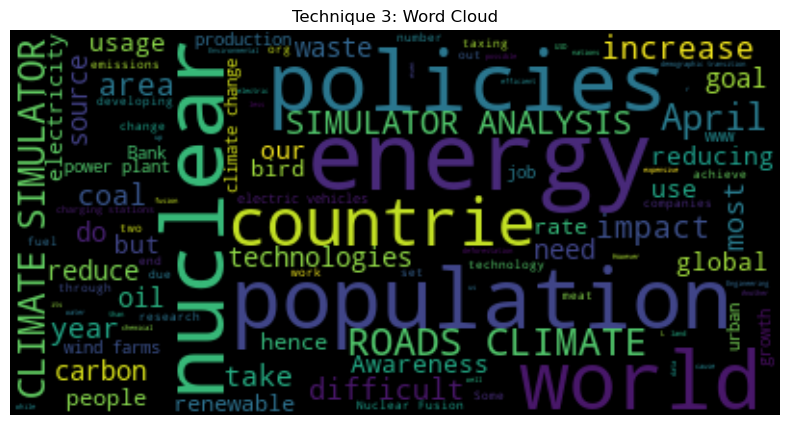

In [63]:
#pip install wordcloud
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]
additional_stopwords = [
    'https', 'retrieved', 'en', 'one', 'new', 'can', 'also', 'used', 'other', 'such', 'many', 'we', 'a', 'these', 'or', 'hence' 
    'the', 'in', 'of', 'to', 'and', 'by', 'on', 'for', 'with', 'as', 'from', 'that', 'will', 'an', 'so', 'at' , 'them', 'into', 'and',
    'be', 'are', 'is', 'it', 'this', 'which', 'more', 'all', 'have', 'not', 'they', 'their', 'should'
]

# Combine the two lists
custom_stopwords.extend(additional_stopwords)
stopwords = set(custom_stopwords)
wordcloud = WordCloud(stopwords=stopwords, max_font_size=50, max_words=100, background_color="black").generate(text)
plt.imshow(wordcloud, interpolation="bilinear")
plt.title('Technique 3: Word Cloud')
plt.axis("off")
plt.show()

### Further restricted the unneeded words using additional variable. Generally speaking, word clouds might not look that useful compared to the previous two but they can be used in the exploratory data analysis phase of NLP to get a quick overview of the text data and to identify prominent keywords. They can help identify the main themes or topics within a large corpus of text.

# Q3

# Part A

In [67]:
tweett = open('tweets.txt','r')

In [68]:
corpus = tweett.read()
print(corpus)

2016: Michael Gove, "If we vote to leave the EU, we will be in an economically stronger position" 2023: "British families are Â£8,300 worse off than those in Germany and France"
Decoding my best song from Northern Ghana in 2023 | King  Ayisiba
â€˜FIVE NIGHTS AT FREDDY'Sâ€™ has surpassed $300M at the worldwide box office!
I got a offer From another Company Thank You 2023
Okay letâ€™s wrap it up, whatâ€™s the most used word/slang in 2023?
"You're part of a legacy" - Anakin Skywalker (Ahsoka 2023)
On a scale of 1-10, how would you rate Joey Logano's 2023 NASCAR Cup Series season?
Canada ranked 2nd best country in the world for 2023. 
This world that continues to bomb these children with 3-meter missiles is a backward, uncivilized, unjust, animalistic, and inhumane world. It is governed by the law of the jungle, not the law of human rights
Data from the Department for Education show that indigenous White British children will become a minority in English state schools by 2037, if current p

# Part B

In [69]:
#line split
corpus = corpus.splitlines()
print(corpus)

['2016: Michael Gove, "If we vote to leave the EU, we will be in an economically stronger position" 2023: "British families are Â£8,300 worse off than those in Germany and France"', 'Decoding my best song from Northern Ghana in 2023 | King  Ayisiba', "â€˜FIVE NIGHTS AT FREDDY'Sâ€™ has surpassed $300M at the worldwide box office!", 'I got a offer From another Company Thank You 2023', 'Okay letâ€™s wrap it up, whatâ€™s the most used word/slang in 2023?', '"You\'re part of a legacy" - Anakin Skywalker (Ahsoka 2023)', "On a scale of 1-10, how would you rate Joey Logano's 2023 NASCAR Cup Series season?", 'Canada ranked 2nd best country in the world for 2023. ', 'This world that continues to bomb these children with 3-meter missiles is a backward, uncivilized, unjust, animalistic, and inhumane world. It is governed by the law of the jungle, not the law of human rights', 'Data from the Department for Education show that indigenous White British children will become a minority in English state

In [72]:
from textblob import TextBlob # Ensure textblob is installed

positive = 0
negative = 0
neutral = 0

for line in corpus:
    analysis = TextBlob(line)
    print(line)
    print(analysis.sentiment)
    if analysis.sentiment.polarity > 0:
        positive += 1
    elif analysis.sentiment.polarity < 0:
        negative += 1
    else:
        neutral += 1 # Counting neutral tweets separately

print("Positive Tweets: ", positive)
print("Negative Tweets: ", negative)
print("Neutral Tweets: ", neutral) # Display the count of neutral tweets




2016: Michael Gove, "If we vote to leave the EU, we will be in an economically stronger position" 2023: "British families are Â£8,300 worse off than those in Germany and France"
Sentiment(polarity=-0.03333333333333335, subjectivity=0.5)
Decoding my best song from Northern Ghana in 2023 | King  Ayisiba
Sentiment(polarity=1.0, subjectivity=0.3)
â€˜FIVE NIGHTS AT FREDDY'Sâ€™ has surpassed $300M at the worldwide box office!
Sentiment(polarity=0.0, subjectivity=0.0)
I got a offer From another Company Thank You 2023
Sentiment(polarity=0.0, subjectivity=0.0)
Okay letâ€™s wrap it up, whatâ€™s the most used word/slang in 2023?
Sentiment(polarity=0.5, subjectivity=0.5)
"You're part of a legacy" - Anakin Skywalker (Ahsoka 2023)
Sentiment(polarity=0.0, subjectivity=0.0)
On a scale of 1-10, how would you rate Joey Logano's 2023 NASCAR Cup Series season?
Sentiment(polarity=0.0, subjectivity=0.0)
Canada ranked 2nd best country in the world for 2023. 
Sentiment(polarity=0.5, subjectivity=0.15)
This wo

### The ouput above shows the count of various sentiments based on 10 tweets that were randomly copied and pasted in the notepad based on the keyword search #2023. 

# Part C

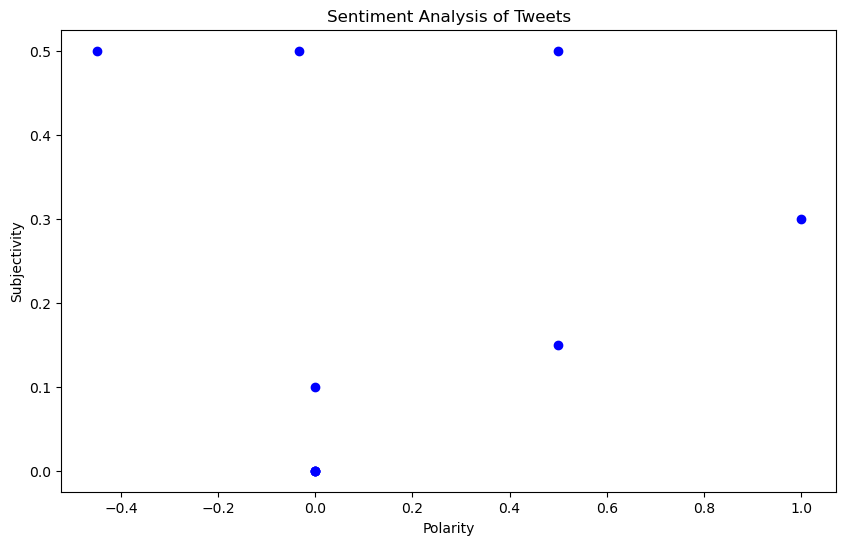

In [74]:
#Lists to hold polarity and subjectivity scores
polarities = []
subjectivities = []

for line in corpus:
    analysis = TextBlob(line)
    polarities.append(analysis.sentiment.polarity)
    subjectivities.append(analysis.sentiment.subjectivity)

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(polarities, subjectivities, color='blue')

# Adding title and labels
plt.title('Sentiment Analysis of Tweets')
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')

# Show the plot
plt.show()

### The scatter plot clearly shows positive or neutral sentiment for the most part among the tweets analyzed, with variation in how objective or subjective each tweet is.

In [75]:
count_positive = 0
count_negative = 0
max_polarity = 0
min_polarity = 0
tweet_max_polarity = ""
tweet_min_polarity = ""

for tweet in corpus:
    sentiment_analysis = TextBlob(tweet)
    if sentiment_analysis.sentiment.polarity >= 0:
        count_positive += 1
        if sentiment_analysis.sentiment.polarity > max_polarity:
            max_polarity = sentiment_analysis.sentiment.polarity
            tweet_max_polarity = tweet
    else:
        count_negative += 1
        if sentiment_analysis.sentiment.polarity < min_polarity:
            min_polarity = sentiment_analysis.sentiment.polarity
            tweet_min_polarity = tweet

print("Max polarity: ", max_polarity)
print("Tweet with max polarity: ", tweet_max_polarity)
print("Min polarity: ", min_polarity)
print("Tweet with min polarity: ", tweet_min_polarity)

Max polarity:  1.0
Tweet with max polarity:  Decoding my best song from Northern Ghana in 2023 | King  Ayisiba
Min polarity:  -0.45
Tweet with min polarity:  This world that continues to bomb these children with 3-meter missiles is a backward, uncivilized, unjust, animalistic, and inhumane world. It is governed by the law of the jungle, not the law of human rights


### The algorithm appears to accurately capture the extremes of sentiment in these two tweets. The first tweet is about a musician which is why it is categorized as positive and uplifting, which is correctly reflected in the high polarity score. The second tweet about bombing and is deeply negative and critical, reflected in the negative polarity score.